# TMAX UTC vs Solar Day Analysis

## Overview

This comprehensive notebook analyzes and compares maximum temperature (TMAX) fields derived from ERA5 data using two different time definitions:

- **UTC Time**: Standard Coordinated Universal Time convention, where all measurements use a single global time reference (UTC midnight)
- **Solar Day Time**: Local solar day convention, where the day definition is based on local solar noon, accounting for longitudinal position

## Key Questions Addressed

1. How do temperature maxima differ when computed using UTC vs. solar day definitions?
2. What is the spatial distribution of these differences across North America?
3. How do the differences vary seasonally and at specific locations?
4. What statistical properties (mean, median, std, skewness, kurtosis) characterize each convention?

## Data

- **Source**: ERA5 reanalysis (1941-2025)
- **Variable**: Daily maximum temperature at 2 meters (TMAX)
- **Domain**: North America, spanning longitudes 182°E-310°E and latitudes 22°N-75°N
- **Resolution**: Full ERA5 spatial resolution

## Workflow

The analysis is structured in the following phases:
1. **Data Loading & Preprocessing** - Import both UTC and SLD datasets, subset to domain, convert units
2. **Global Statistics** - Compute temporal statistics (mean, median, std, skewness, kurtosis) and RMSE differences
3. **Spatial Visualization** - Map instantaneous temperature fields and highlight locations of interest
4. **Point-Based Comparisons** - Extract time series for 5 major cities and compare distributions
5. **Distribution Analysis** - Explore differences through multiple visualization techniques
6. **Temporal Evolution** - Examine seasonal and inter-annual variations in the UTC-SLD differences

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy
import scipy
from matplotlib import cm
from xhistogram.xarray import histogram
from scipy.stats import kurtosis,skew
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
import gc

In [3]:
import taylor
import statsmodels.api as sm
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
def preprocess(ds):
    return ds.\
            sel(lon=slice(lon_min,lon_max)).\
            sel(lat=slice(lat_max,lat_min))

### Function Definitions: Data Preprocessing

Two preprocessing functions are defined to standardize data loading:

1. **`preprocess(ds)`**: Subsets each dataset to the spatial domain defined by (lon_min, lon_max, lat_min, lat_max). Applied during multi-file dataset opening to reduce memory footprint.

## Step 1: Load and Preprocess Data

### Objective
Import ERA5 maximum temperature datasets for both UTC and solar-day time conventions from individual year files (1941-2025). Subset data to the analysis domain, handle coordinate wrapping, and convert from Kelvin to Celsius.

### Procedure

**Step 1.1: Set Analysis Parameters**

Define the temporal range (1941-2025) and the spatial domain covering North America:

In [6]:
yearb=1941
yeare=2025
lon_min=182;lon_max=310
lat_min=22;lat_max=75


**Parameters:**
- `yearb=1941, yeare=2025`: 85-year temporal window covering 1941 through 2025
- `lon_min=182, lon_max=310`: Longitude range (182°E to 310°E = 178°W), covering North America
- `lat_min=22, lat_max=75`: Latitude range (22°N to 75°N), from Mexico through Alaska

**Step 1.2: Load UTC-based TMAX Dataset**

The following steps load 85 years of UTC time-based TMAX files from individual year files:

In [7]:

files = [f"~/data/ERA5/UTCTime/tmax.2m.{iyear}.UTC.nc" for iyear in range(yearb, yeare+1)]
tmaxUTC = xr.open_mfdataset(files,preprocess=preprocess)
tmaxUTC['lon'] = (tmaxUTC['lon'] + 180) % 360 - 180                                                                                                           
tmaxUTC = tmaxUTC.sortby(tmaxUTC.lon)
tmaxUTC = tmaxUTC.sortby(tmaxUTC.lat)


- Open 85 years of UTC time-based TMAX files
- Apply spatial preprocessing to subset to study domain
- Wrap longitude coordinates from (0, 360) to (-180, 180) for consistency
- Sort both longitude and latitude for proper indexing

**Step 1.3: Load Solar-Day-based TMAX Dataset**

In [8]:

files = [f"~/data/ERA5/SLDTime/tmax.2m.{iyear}.FromSolarDayTime.nc" for iyear in range(yearb, yeare+1)]
tmaxSLD = xr.open_mfdataset(files,preprocess=preprocess)
tmaxSLD['lon'] = (tmaxSLD['lon'] + 180) % 360 - 180                                                                                                           
tmaxSLD = tmaxSLD.sortby(tmaxSLD.lon)
tmaxSLD = tmaxSLD.sortby(tmaxSLD.lat)

- Open 85 years of solar day time-based TMAX files
- Apply identical spatial preprocessing and coordinate handling as UTC dataset
- Ensure both datasets are comparable (same domain, same coordinate system)

In [9]:
gc.collect()

0

In [10]:
tmaxUTC = tmaxUTC.load()

In [11]:
gc.collect()

3422

In [12]:

tmaxSLD = tmaxSLD.load()

In [13]:
gc.collect()

5045

**Step 1.5: Convert Temperature Units and Define Global Properties**

- Subtract 273.15 from both datasets to convert from Kelvin to Celsius
- Define units string for use in plot labels
- Load Natural Earth state borders for cartographic reference

---

In [14]:
tmaxUTC['tmax'] = tmaxUTC['tmax'] - 273.15
tmaxSLD['tmax'] = tmaxSLD['tmax'] - 273.15
units = f'$\degree$C'

In [15]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

---

## Step 2: Compute Global Statistics

### Objective
Calculate temporal statistics for both datasets across the entire spatial domain and time period to quantify systematic differences between UTC and solar-day time conventions.

### Approach

**Statistics to be Computed:**

For each dataset (UTC and SLD):

In [16]:
TskewnessUTC = tmaxUTC['tmax'].reduce(func=scipy.stats.skew, dim="time")
TkurtosisUTC = tmaxUTC['tmax'].reduce(func=scipy.stats.kurtosis, dim="time")
TmeanUTC = tmaxUTC['tmax'].mean('time')
TmedianUTC = tmaxUTC['tmax'].median('time')
TstdUTC = tmaxUTC['tmax'].std('time')


TskewnessSLD = tmaxSLD['tmax'].reduce(func=scipy.stats.skew, dim="time")
TkurtosisSLD = tmaxSLD['tmax'].reduce(func=scipy.stats.kurtosis, dim="time")
TmeanSLD = tmaxSLD['tmax'].mean('time')
TmedianSLD = tmaxSLD['tmax'].median('time')
TstdSLD = tmaxSLD['tmax'].std('time')


RMSE = np.sqrt(((tmaxUTC['tmax']-tmaxSLD['tmax'])**2).mean('time'))

- **Mean** - Temporal average temperature across 85 years at each grid point
- **Median** - 50th percentile value (robust central tendency, less affected by extremes)
- **Std** - Standard deviation of temperature values (measure of temporal variability)
- **Skewness** - Asymmetry of the distribution (positive = right-skewed warm tail, negative = left-skewed)
- **Kurtosis** - Heavy-tailedness of the distribution (positive = fat tails, negative = thin tails)
- **RMSE** - Root mean square error between UTC and SLD datasets at each grid point

These statistics enable comparison of the two time conventions from both climatological and statistical distribution perspectives.

Text(0.5, 0.98, 'RMSE UTC-SLD (1941-2025)')

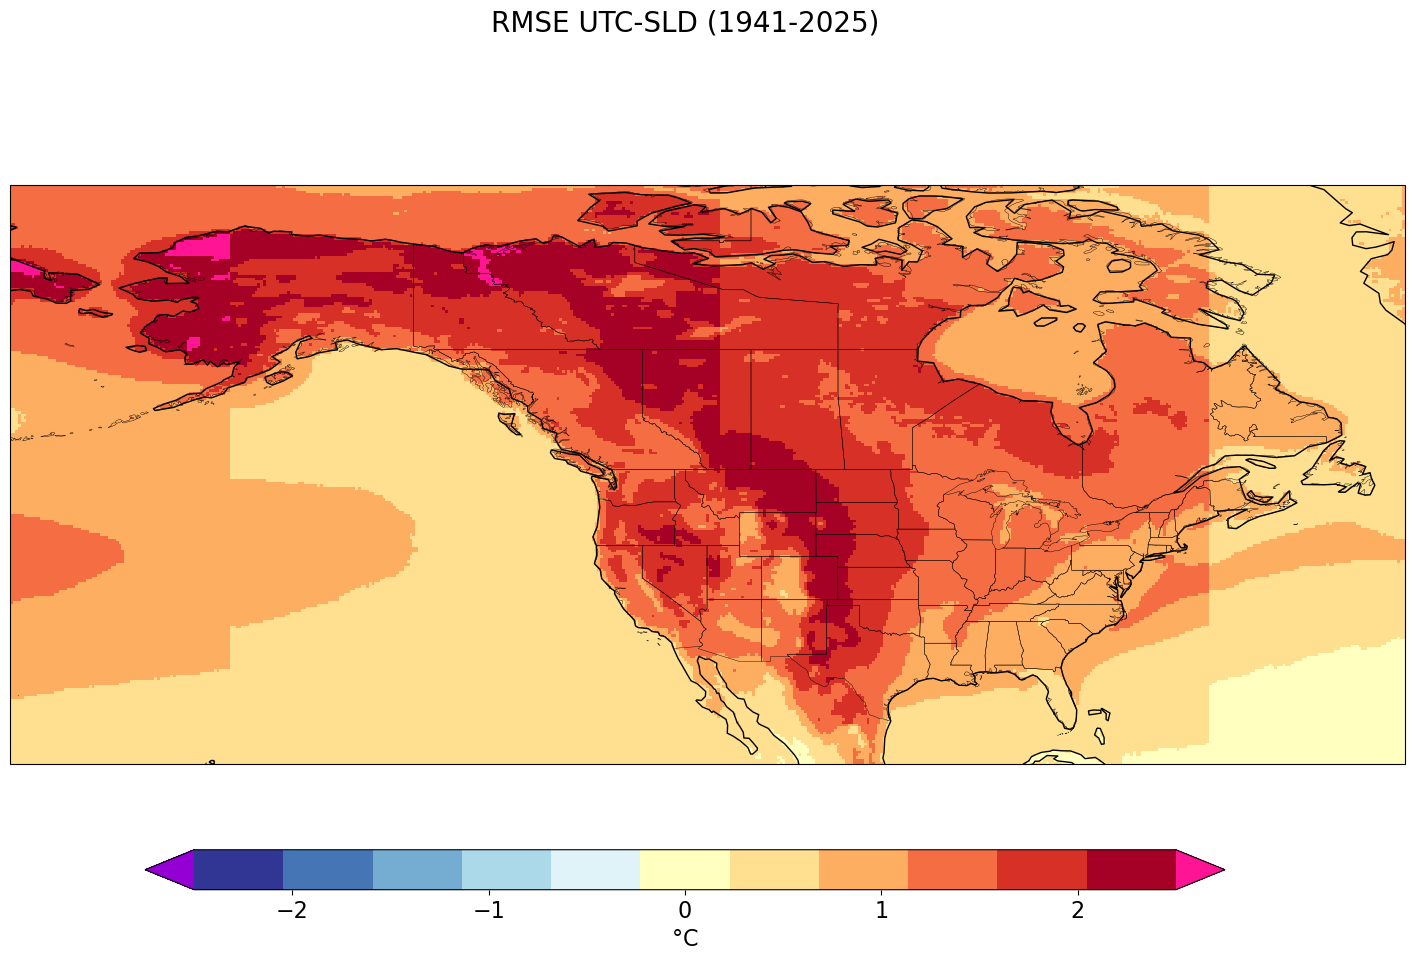

In [17]:
clevs=np.arange(-2.5,3,0.5)
cmap = cm.get_cmap('RdYlBu_r',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,10),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)

cc=RMSE.plot(ax=ax,cmap=cmap,norm=norm,add_colorbar=False)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax.coastlines()


ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,orientation='horizontal',extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label=f'{units}',fontsize=16)


plt.suptitle(f'RMSE UTC-SLD ({yearb}-{yeare})', fontsize=20)

### Figure: Spatial Distribution of RMSE (UTC vs SLD)

This map shows the Root Mean Square Error (RMSE) between UTC and SLD temperature maxima averaged over the entire 85-year period.

**Color Interpretation:**
- **Blue tones**: SLD values tend to be warmer than UTC (positive bias in SLD)
- **Red tones**: SLD values tend to be cooler than UTC (negative bias in SLD)
- **White/neutral**: Minimal differences between UTC and SLD

**Geographic Patterns:**
- Differences are expected to correlate with longitude due to the solar day definition
- Western regions (far west US/Canada): Different phase relative to UTC
- Eastern regions: Smaller differences as local solar time approaches UTC


**Step 2.2: Extract Time Series from 5 Benchmark Cities**
Extract 1-dimensional time series from 5 major US cities to enable point-wise comparison:
These cities span a ~75° longitude range, allowing investigation of how UTC-SLD differences vary with position.
| City | Latitude | Longitude | Region | Significance|
| -------- | -------- | -------- | -------- |-------- |
| NYC | 40.7°N | -74.0° | Northeast | Eastern coast |
| Chicago | 41.8°N | -87.6° | Upper Midwest | Central time zone |
| Denver | 39.7°N | -105.0° | Mountain West | High elevation, central US |
| San Francisco | 37.8°N | -122.4° | Pacific Coast | Western coast |
| Fairbanks | 64.8°N | -147.8° | Alaska | High latitude, far west |

In [33]:
FairbanksUTC = tmaxUTC['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
SanFranciscoUTC = tmaxUTC['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
DenverUTC = tmaxUTC['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
ChicagoUTC = tmaxUTC['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCUTC = tmaxUTC['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')


FairbanksSLD = tmaxSLD['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
SanFranciscoSLD = tmaxSLD['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
DenverSLD = tmaxSLD['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
ChicagoSLD = tmaxSLD['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCSLD = tmaxSLD['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')


In [34]:
UTC = [FairbanksUTC, SanFranciscoUTC, DenverUTC, ChicagoUTC, NYCUTC]
SLD = [FairbanksSLD, SanFranciscoSLD, DenverSLD, ChicagoSLD, NYCSLD]
tip = ['Fairbanks', 'SanFrancisco', 'Denver', 'Chicago', 'NYC' ]

---

## Step 3: Visualize Instantaneous Spatial Fields

Plot the spatial distribution of UTC-based maximum temperature at day 182 (late June) with city locations highlighted:

### Objective

Display maps of the temperature fields at a single time step to illustrate spatial structure and mark the 5 benchmark cities for reference.**Step 3.1: Map UTC TMAX Field**


### Procedure

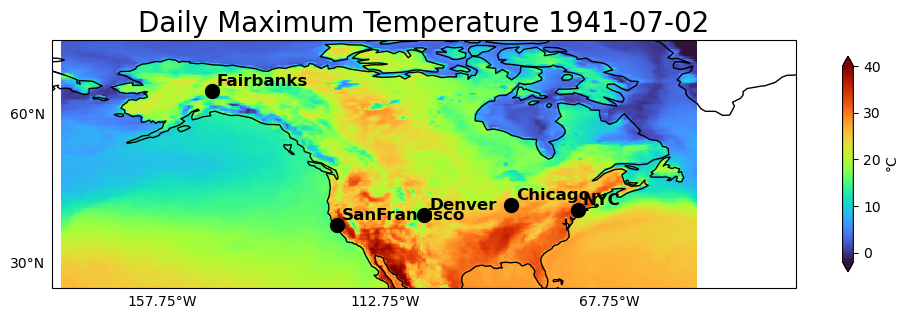

In [35]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,8),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax,cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.35},vmin=-2,vmax=40) 
for i in range(len(tip)):
    ax.plot(UTC[i]['lon'], UTC[i]['lat'], marker='o', color='black', markersize=10, transform=proj)
    ax.text(UTC[i]['lon']+1, UTC[i]['lat']+1, tip[i], fontsize=12, fontweight='bold', color='black', transform=proj)
gl1 = ax.gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax.add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax.set_extent([-180, -30, 25, 75], crs=ccrs.PlateCarree())
ax.set_title('UTC',fontsize=20)
custom_xticks = [0-180, 22.25-180, 67.25-180,112.25-180,157.25-180, 180-180, 202.25-180,247.25-180,292.25-180,337.25-180,360-180]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner

gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.title(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

In [36]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',\
            '#e41a1c', '#a65628', '#984ea3',\
            '#999999', '#f781bf', '#dede00']

**Color Palette Definition:**
Define a colorblind-friendly palette for consistent use across all multi-series plots:
- Index [0] (#377eb8): Blue for UTC values
- Index [1] (#ff7f00): Orange for SLD values

In [37]:
for i in range(len(tip)):
   print(tip[i], 'min:', UTC[i].min().data, 'max:', SLD[i].max().data)


Fairbanks min: -52.698883 max: 34.36075
SanFrancisco min: 2.219513 max: 34.806213
Denver min: -23.050629 max: 38.12668
Chicago min: -21.491821 max: 36.299835
NYC min: -14.487274 max: 39.08188


---

## Step 4: Compare UTC vs SLD Distributions Using Summer Data

Compare the distribution shapes across 5 cities using overlaid histograms (2-degree bins):

### Objective

Compare the probability distributions of UTC and SLD maximum temperatures during the summer season (June-August) to understand whether systematic differences exist across the temperature range.**Step 4.1: Probability Density Functions (Histograms)**



### Summer Focus### Approach

Summer months are chosen because:

- Highest absolute temperatures facilitate detection of small relative differences- UTC-SLD differences expected to be most pronounced during high-temperature periods
- Most stable weather patterns reduce day-to-day variability

Text(0.5, 0.98, 'UTC vs SLD Tmax, Summer (June-August)')

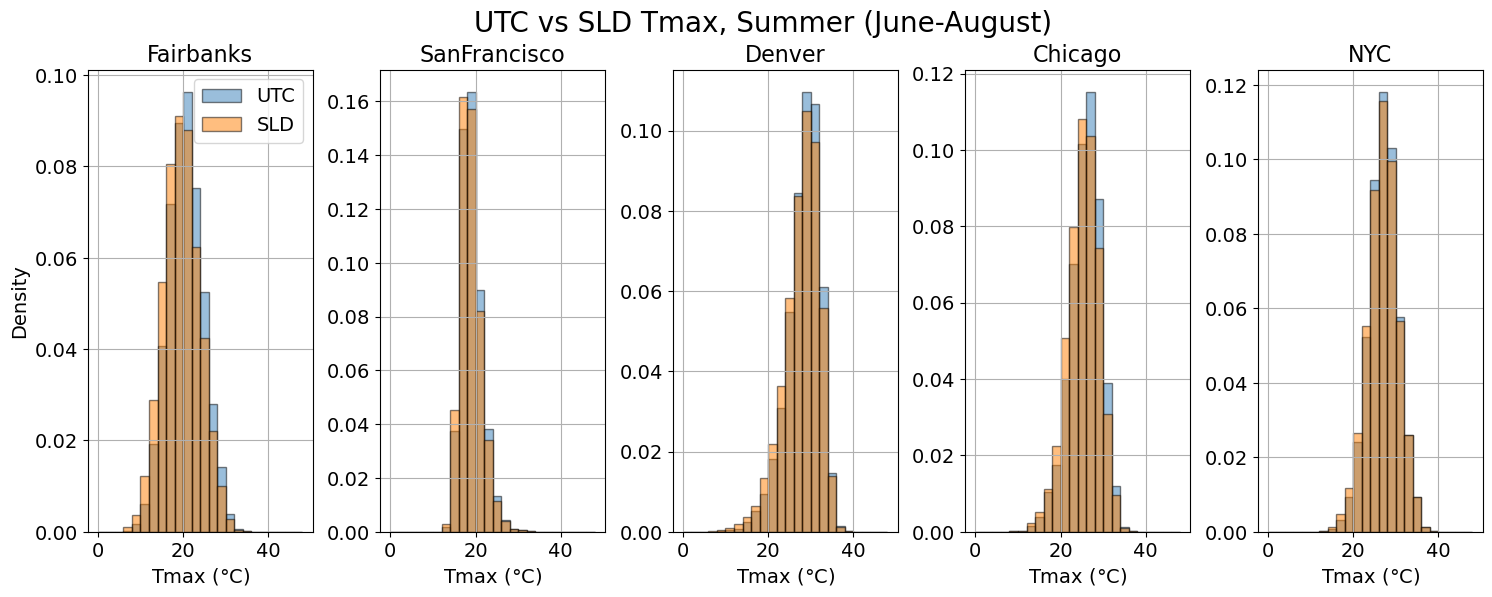

In [38]:
####
##### PDF Plot
#####
i=1
delta = 2
bins = np.arange(0,50,delta)
x100 = (bins[1:]+bins[:-1])*0.5


fig, ax = plt.subplots(nrows=1,ncols=len(tip),figsize=(18,6))
fig.subplots_adjust(wspace=0.3)

for i in range(len(tip)):
  dhUTC=histogram(UTC[i].sel(time=UTC[i].time.dt.month.isin([6,7,8])), bins=bins,density=True, block_size=None)
  ax[i].bar((bins[1:]+bins[:-1])*0.5,dhUTC.data,edgecolor='k',color=CB_color[0], width=np.diff(bins), label='UTC', alpha=0.5)

  dhSLD=histogram(SLD[i].sel(time=SLD[i].time.dt.month.isin([6,7,8])), bins=bins,density=True, block_size=None)
  ax[i].bar((bins[1:]+bins[:-1])*0.5,dhSLD.data,edgecolor='k',color=CB_color[1],width=np.diff(bins), label='SLD', alpha=0.5) 
  ax[i].grid()

  ax[i].set_xlabel(f"Tmax ({units})",fontsize=14)
  ax[i].set_ylabel("",fontsize=14)
  ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=14)
  ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=14)
  ax[i].set_title(f'{tip[i]}',fontsize=16)
ax[0].legend(fontsize=14)  
ax[0].set_ylabel(f"Density",fontsize=14)
plt.suptitle(f'UTC vs SLD Tmax, Summer (June-August)',fontsize=20)  

### Interpretation: Probability Density Functions

**Figure 4.1: Summer TMAX Distribution Histograms**

This figure displays overlaid histograms of UTC (blue) and SLD (orange) maximum temperatures during summer months (June-August) for each benchmark city. Bin width = 2°C, with density normalized by total count.

**Key Observations:**
- **Distribution Shape**: Compare whether UTC and SLD distributions have similar or distinct shapes across temperature ranges
- **Peak Position**: Horizontal shifts between peaks indicate systematic bias (warmer or cooler under one convention)
- **Distribution Width**: Differences in spread suggest changes in temporal variability
- **City-to-City Variation**: Note how the degree of overlap and shift varies from west (Fairbanks, Denver, SF) to east (Chicago, NYC)

**Expected Pattern:**
- Western cities should show larger differences due to greater deviation from UTC
- Eastern cities should show closer distributions as local solar time approaches UTC

**Step 4.2: Scatter Plot (UTC vs SLD Values)**

Text(0.5, 0.98, 'UTC vs SLD Tmax, Summer (June-August)')

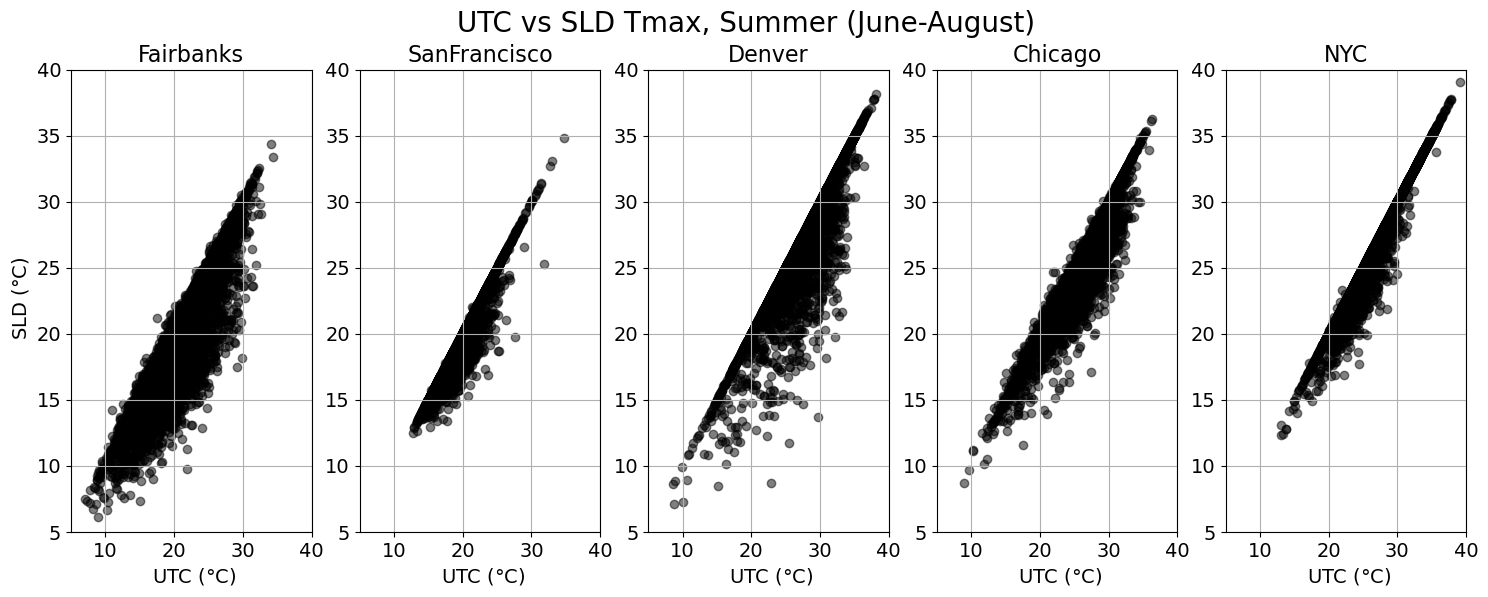

In [39]:
####
##### Scatter Plot
#####

fig, ax= plt.subplots(nrows=1,ncols=len(tip),figsize=(18,6))

for i in range(len(tip)):
  ax[i].scatter(UTC[i].sel(time=UTC[i].time.dt.month.isin([6,7,8])), SLD[i].sel(time=SLD[i].time.dt.month.isin([6,7,8])), color='black', alpha=0.5)         
  ax[i].grid()
  ax[i].set_xlim([5, 40])
  ax[i].set_ylim([5, 40])
  ax[i].set_xlabel(f" UTC ({units})",fontsize=14)
  ax[i].set_ylabel(f"",fontsize=14)
  ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=14)
  ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=14)
  ax[i].set_title(f'{tip[i]}',fontsize=16)
ax[0].set_ylabel(f" SLD ({units})",fontsize=14)
plt.suptitle(f'UTC vs SLD Tmax, Summer (June-August)',fontsize=20)  

### Interpretation: Scatter Plot (UTC vs SLD)

**Figure 4.2: Paired Temperature Comparison**

This figure shows paired UTC and SLD daily maximum temperatures during summer for each city. Each point represents a single day's maximum temperature.

**Reference Lines:**
- The red diagonal (1:1 line) represents perfect agreement between UTC and SLD values
- Points above the line: SLD > UTC (SLD records warmer maxima)
- Points below the line: SLD < UTC (SLD records cooler maxima)

**Key Observations:**
- **Systematic Bias**: Check whether points cluster systematically above or below the 1:1 line
- **Scatter Density**: Tightly clustered points indicate consistent relationship; dispersed points indicate variable differences
- **Range Comparison**: Which dataset tends to have higher maxima?
- **Longitudinal Effect**: Compare patterns across the 75° longitude span from Fairbanks to NYC

**Interpretation Significance:**
- Systematic deviations reveal that UTC and SLD do not capture the "true" maximum uniformly
- Understanding which convention gives higher/lower values is crucial for climate impact studies

**Step 4.3: Box Plot (Distribution Summary)**


Text(0.5, 0.98, 'UTC vs SLD Tmax, Summer (June-August)')

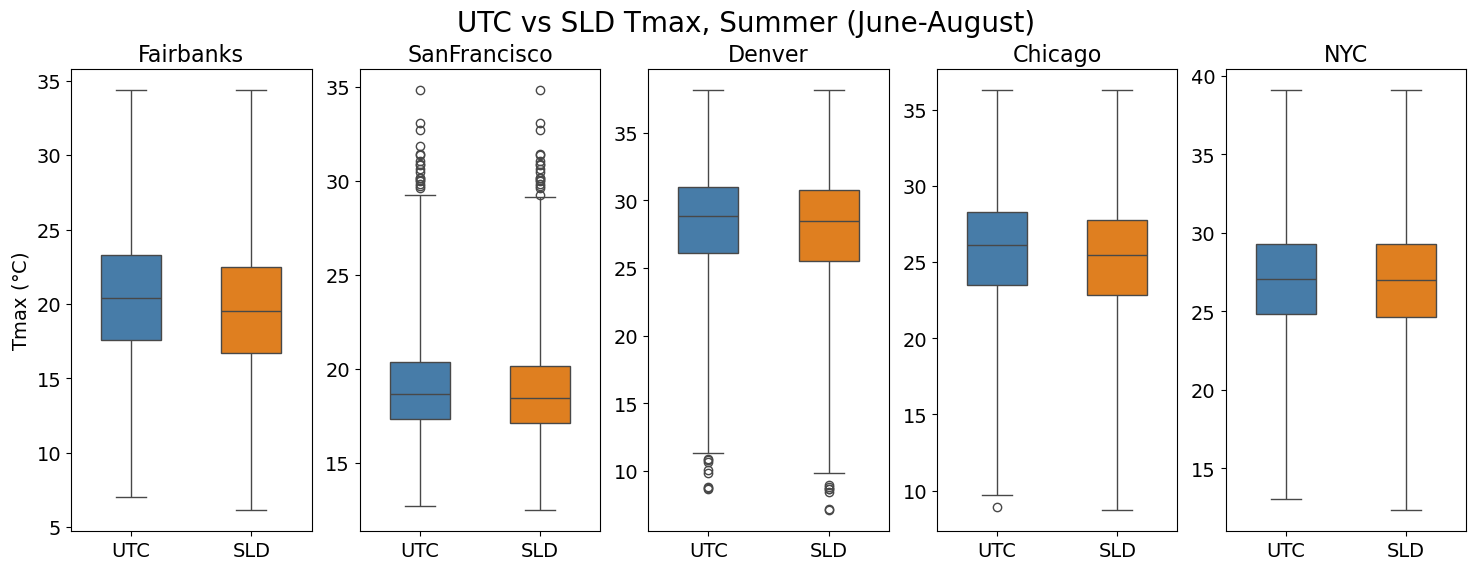

In [40]:

fig, ax= plt.subplots(nrows=1,ncols=len(tip),figsize=(18,6))
for i in range(len(tip)):
    data_a = UTC[i].sel(time=UTC[i].time.dt.month.isin([6,7,8])).data
    data_b = SLD[i].sel(time=SLD[i].time.dt.month.isin([6,7,8])).data
    g = sns.boxplot(data=[data_a, data_b],palette=[CB_color[0], CB_color[1]],whis=3,width=0.5,ax=ax[i])
    ax[i].set_ylabel(f'',fontsize=14)
    ax[i].set_xticks([0,1])
    ax[i].set_xticklabels(["UTC","SLD"])
    ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=14)
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=14)
    ax[i].set_title(f'{tip[i]}',fontsize=16)
ax[0].set_ylabel(f'Tmax ($\degree$C)',fontsize=14)    
plt.suptitle(f'UTC vs SLD Tmax, Summer (June-August)',fontsize=20)  

### Interpretation: Box Plot Summary Statistics

**Figure 4.3: Distribution Quartiles and Outliers**

This figure shows box plots comparing UTC and SLD distributions. Each box summarizes the quartile structure and outlier information.

**Box Plot Components:**
- **Horizontal Line in Box**: Median (50th percentile) - the "middle" value
- **Box Edges**: 25th and 75th percentiles (interquartile range, IQR) - contains 50% of data
- **Whiskers**: Extend to ±1.5 × IQR from box edges or to actual min/max
- **Individual Points**: Outliers beyond the whiskers (using whis=3 criterion)

**Comparisons to Make:**
- **Median Shift**: Are the medians (middle lines) at different heights?
- **Box Height (Spread)**: Which distribution is more compact or spread out?
- **Outlier Frequency**: Which dataset has more extreme values?
- **Symmetry**: Are boxes centered, or skewed within their whisker range?

**Practical Implications:**
- Median differences indicate systematic bias in "typical" maximum temperatures
- IQR differences reveal whether one convention captures more or less variability in normal conditions
- Outlier distributions show which convention produces more extreme values

**Step 4.4: Violin Plot (Full Distribution Shape)**


Text(0.5, 0.98, 'UTC vs SLD Tmax, Summer (June-August)')

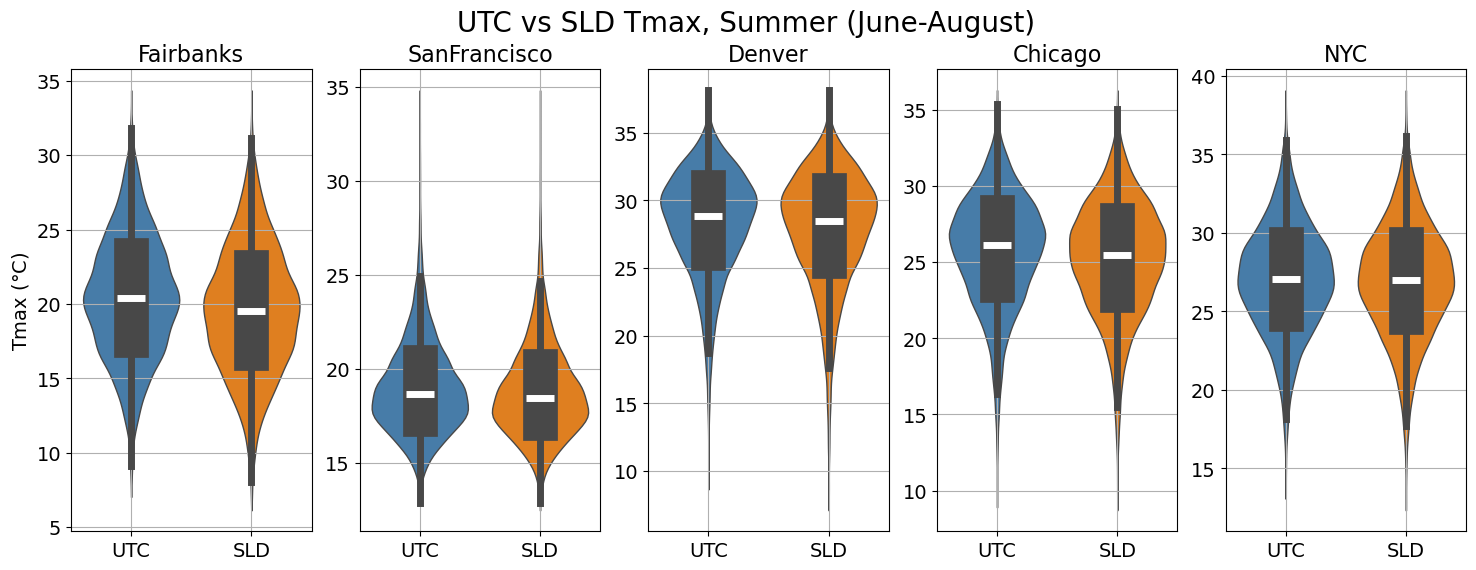

In [41]:

fig, ax= plt.subplots(nrows=1,ncols=len(tip),figsize=(18,6))
for i in range(len(tip)):
    data_a = UTC[i].sel(time=UTC[i].time.dt.month.isin([6,7,8])).data
    data_b = SLD[i].sel(time=SLD[i].time.dt.month.isin([6,7,8])).data
    df = pd.DataFrame({'Tmax': np.concatenate([data_a, data_b]), 'var': np.concatenate([np.repeat('UTC', len(data_a)), np.repeat('SLD', len(data_b))])})
    sns.violinplot(data=df, x="var", y="Tmax", inner="box",palette=[CB_color[0], CB_color[1]], cut=0, inner_kws=dict(whis_width=5,box_width=25),linewidth=1,ax=ax[i])

    ax[i].set_ylabel(f'',fontsize=14)
    ax[i].set_xlabel(f'',fontsize=14)
    ax[i].set_xticks([0,1])
    ax[i].grid()
    ax[i].set_xticklabels(["UTC","SLD"])
    ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=14)
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=14)
    ax[i].set_title(f'{tip[i]}',fontsize=16)
ax[0].set_ylabel(f'Tmax ($\degree$C)',fontsize=14)    
plt.suptitle(f'UTC vs SLD Tmax, Summer (June-August)',fontsize=20)  

### Interpretation: Violin Plot (Full Distribution Shape)

**Figure 4.4: Kernel Density Estimation of Distributions**

This figure uses violin plots to show the complete probability density function (PDF) shape for each convention, with inner quartile boxes overlaid.

**Violin Plot Features:**
- **Width of the Violin**: Wider sections indicate higher frequency of temperatures at that value (kernel density estimate)
- **Overall Shape**: Tells you about skewness and multimodality
- **Symmetric vs. Asymmetric**: Indicates whether distribution is balanced or skewed
- **Inner Box**: Same quartile information as box plots
- **Symmetry**: Vertical symmetry indicates symmetric distribution; asymmetry indicates skew

**Interpretations:**
- **Bimodal/Multimodal**: Are there multiple peaks? (suggests seasonal or weather-pattern-driven multimodality)
- **Fat vs. Thin Tails**: Wider tails show more extreme events at that temperature
- **Location Shift**: If violins are offset vertically, one convention has systematically different temperatures
- **Shape Differences**: Different PDF shapes suggest the conventions capture different aspects of the diurnal cycle

**Climate Implications:**
- Distribution shape matters for extreme event frequency and intensity
- Differences in tail structure affect calculations of heat wave frequency or extreme temperature percentiles

**Step 4.5: Q-Q Plot (Quantile-Quantile Comparison)**


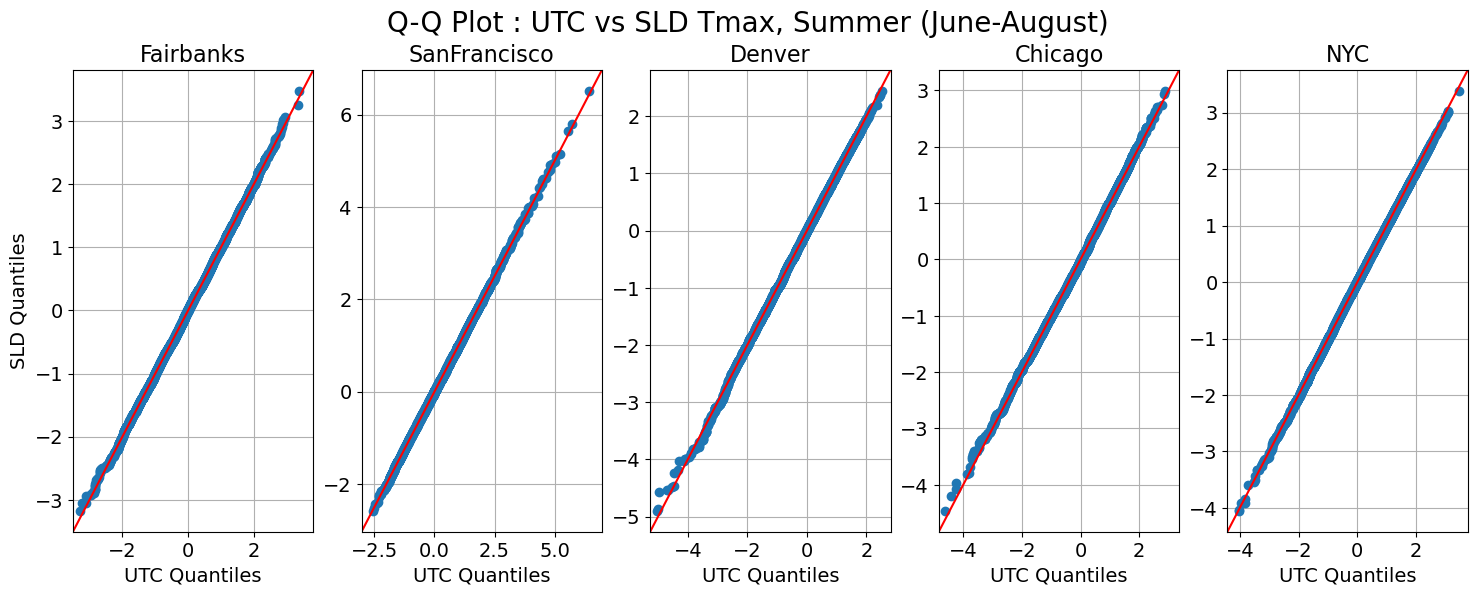

In [42]:
i=2
fig, ax= plt.subplots(nrows=1,ncols=len(tip),figsize=(18,6))
for i in range(len(tip)):

  pp_A = sm.ProbPlot(UTC[i].sel(time=UTC[i].time.dt.month.isin([6,7,8])).data,fit=True)
  pp_B = sm.ProbPlot(SLD[i].sel(time=SLD[i].time.dt.month.isin([6,7,8])).data,fit=True)

  # 3. Plot the quantiles of dataset_A against dataset_B
  pp_B.qqplot(other=pp_A, line="45", ax=ax[i])
  ax[i].grid()
  #ax[i].set_xlim([5, 40])
  #ax[i].set_ylim([5, 40])
  ax[i].set_xlabel(f"UTC Quantiles",fontsize=14)
  ax[i].set_ylabel(f"",fontsize=14)
  ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=14)
  ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=14)
  ax[i].set_title(f'{tip[i]}',fontsize=16)
ax[0].set_ylabel(f"SLD Quantiles",fontsize=14)
plt.suptitle(f'Q-Q Plot : UTC vs SLD Tmax, Summer (June-August)',fontsize=20)  

plt.show()

### Interpretation: Q-Q Plot (Quantile-Quantile Comparison)

**Figure 4.5: Quantile Agreement Between UTC and SLD**

This figure compares quantiles of the two distributions. The red diagonal line (45° line) represents perfect agreement.

**Q-Q Plot Basics:**
- **X-axis**: Quantiles (ordered values) from UTC distribution
- **Y-axis**: Corresponding quantiles from SLD distribution
- **Perfect Agreement**: Points lying exactly on the red 45° diagonal line

**Deviations from the 1:1 Line Reveal:**
- **Parallel Shift (above/below line)**: Systematic location difference (e.g., SLD consistently 1-2°C warmer/cooler)
- **Slope Change (steep/flat)**: Scale difference (one convention has greater spread)
- **Curved Pattern**: Distributional shape difference (e.g., skewness differs)
- **S-Shape**: Tail differences (extreme values differ)

**Interpretation by Region:**
- **Lower tail** (cool temperatures, left side): How winter/cool-day maxima compare
- **Middle** (middle of range): How typical maxima compare
- **Upper tail** (warm temperatures, right side): How summer heat waves compare

**Key Insight:**
If the Q-Q plot significantly deviates from the diagonal, the two conventions are not just shifted versions of each other—they capture fundamentally different aspects of the temperature distribution. This has major implications for extremes-based climate analyses.

---

## Step 5: Temporal Analysis of UTC-SLD Differences

### Objective
Examine how the differences between UTC and SLD temperatures vary over time, including seasonal cycles and long-term trends at the 5 benchmark cities.

### Focus Areas
- **Seasonal Cycles**: How UTC-SLD differences change throughout the year
- **Full Record**: 85-year trends and interannual variability
- **Seasonal Zooms**: Detailed comparison during summer and winter extremes

### Approach

### Interpretation: Seasonal Cycle of UTC-SLD Differences

**Figure 5.1: Day-of-Year Averaged Differences (All Years Combined)**

This figure plots the mean difference (UTC - SLD) as a function of day-of-year, averaged across all 85 years in the record. A smooth seasonal cycle emerges.

**What This Shows:**
- **Positive Values**: Days when UTC maximum exceeds SLD maximum
- **Negative Values**: Days when SLD maximum exceeds UTC maximum  
- **Zero Crossings**: Days of the year when the two conventions produce nearly identical results
- **Amplitude**: The magnitude of the difference reveals the importance of the time convention choice

**Expected Seasonal Pattern:**
- Due to solar geometry, differences should follow an annual cycle
- Phase of the cycle depends on latitude and longitude (seasonal variation in local solar time vs UTC)
- Peak differences typically occur during spring/fall transitions when solar noon timing shifts most rapidly

**Key Question:**
- Do differences show a consistent annual cycle, or is variability high?
- Which season shows largest UTC-SLD divergence?
- Does the pattern differ significantly between the 5 cities (west to east)?

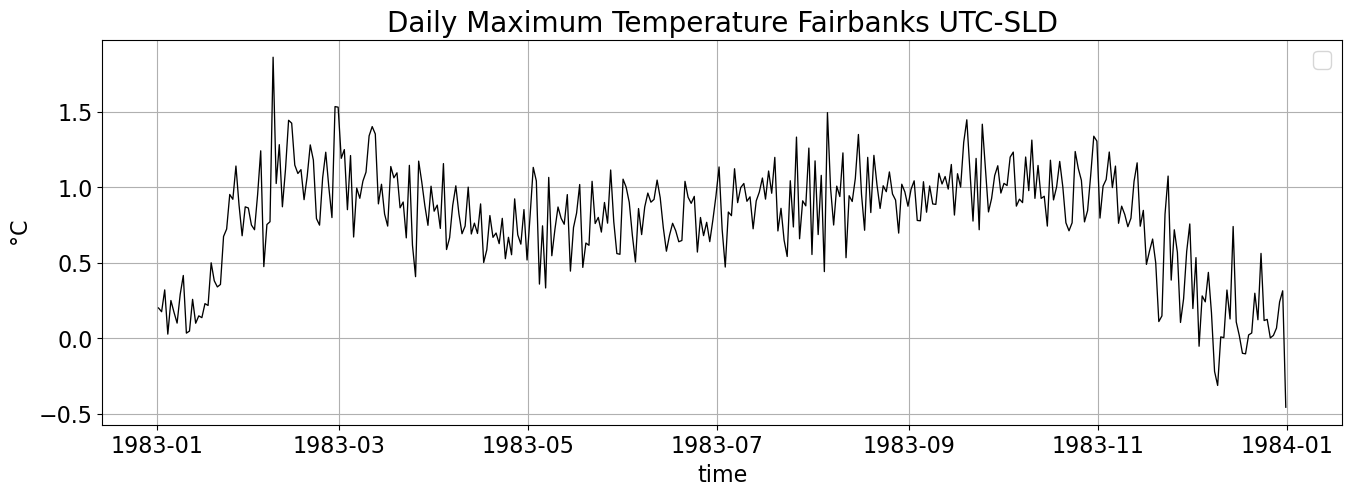

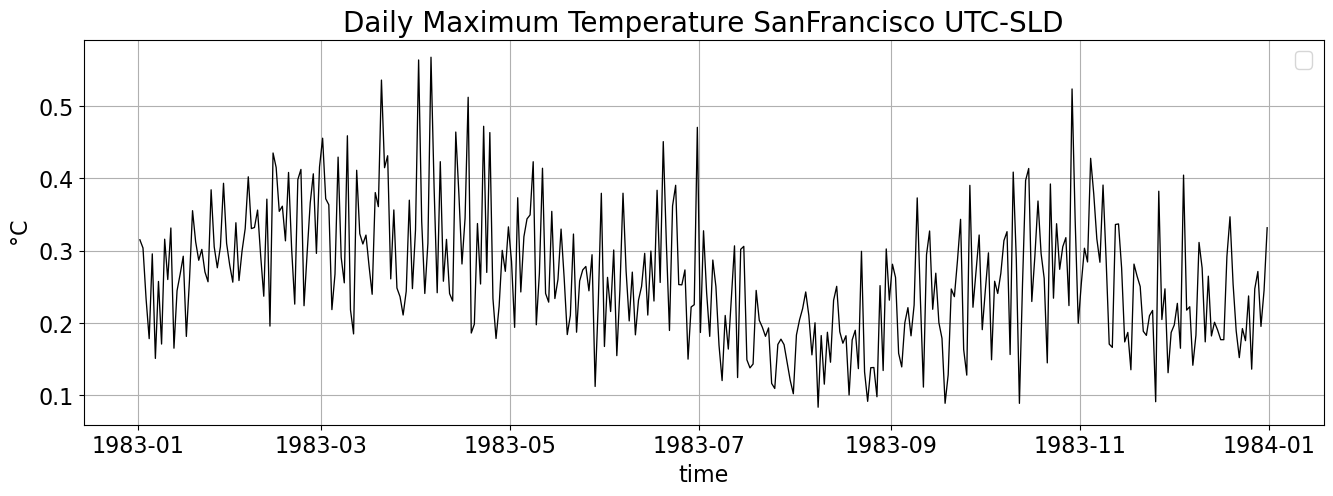

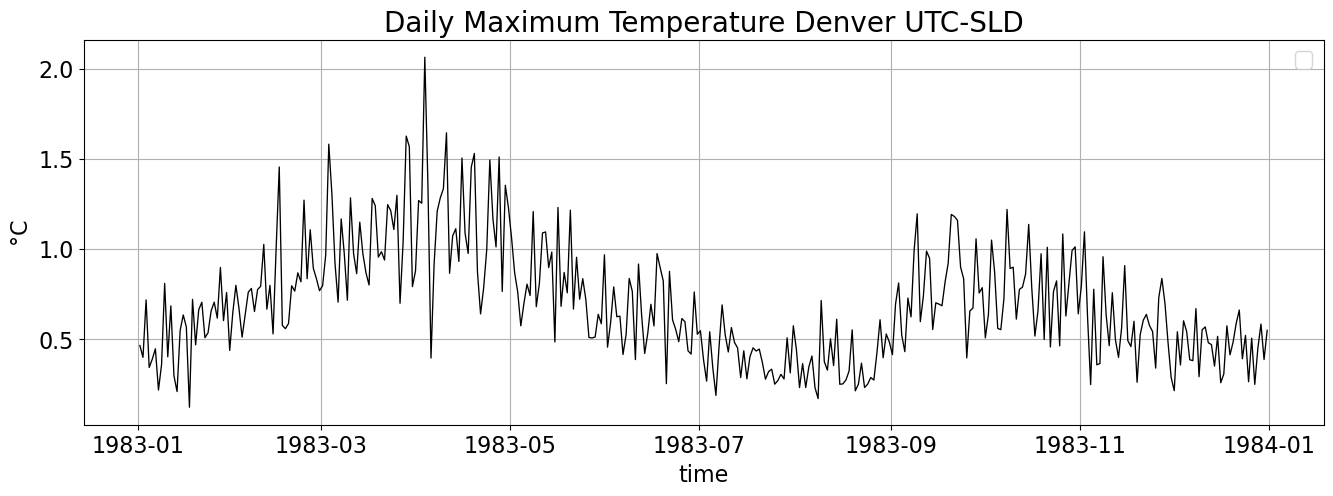

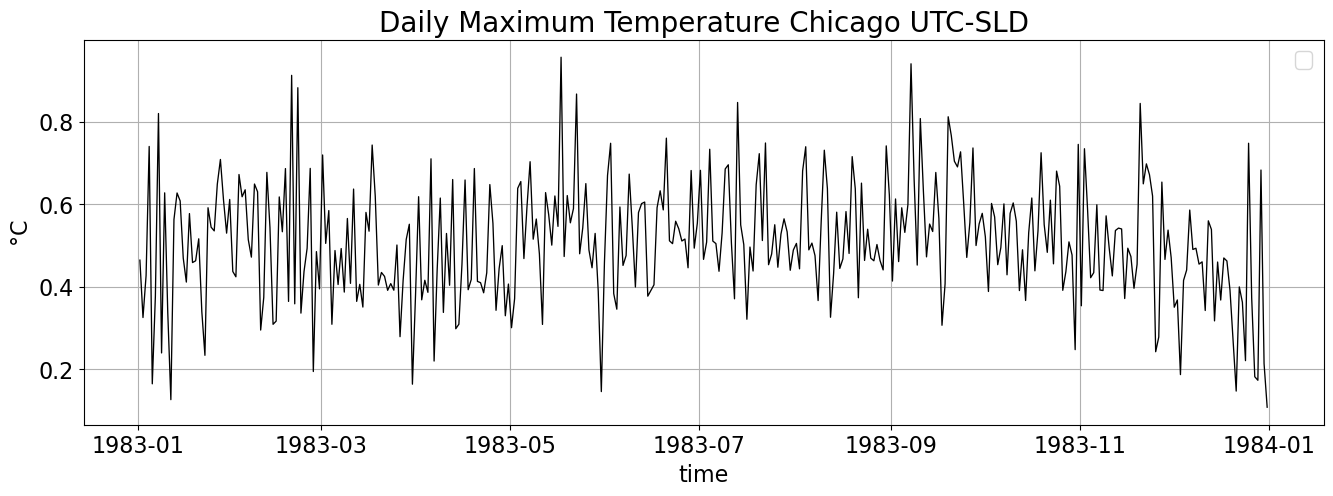

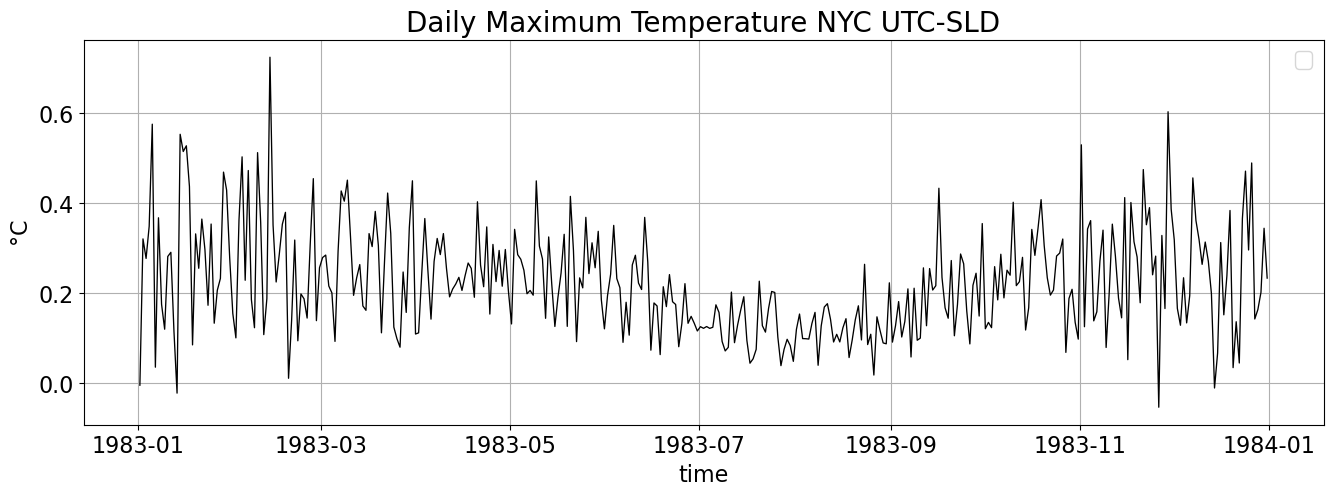

In [44]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].groupby(tmaxUTC['time'].dt.dayofyear).mean()[0:365],(UTC[ip]-SLD[ip]).groupby(tmaxUTC['time'].dt.dayofyear).mean()[0:365],color='k',linewidth=0.95)
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Daily Maximum Temperature {tip[ip]} UTC-SLD',fontsize=20)
  plt.show()

#- Peak differences often occur in spring/fall transitions

#**Interpretation:**- Negative values indicate SLD maxima exceed UTC maxima

#- Smooth seasonal cycle of UTC - SLD differences reveals systematic biases tied to solar geometry- Positive values indicate UTC maxima exceed SLD maxima

**Step 5.2: Full Time Series (All Years)**

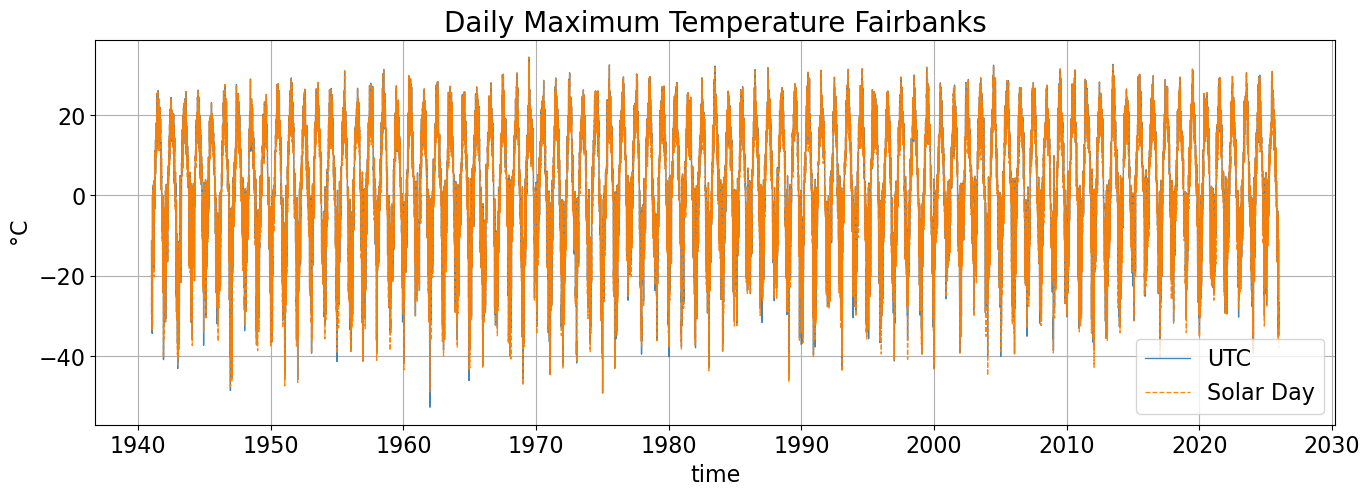

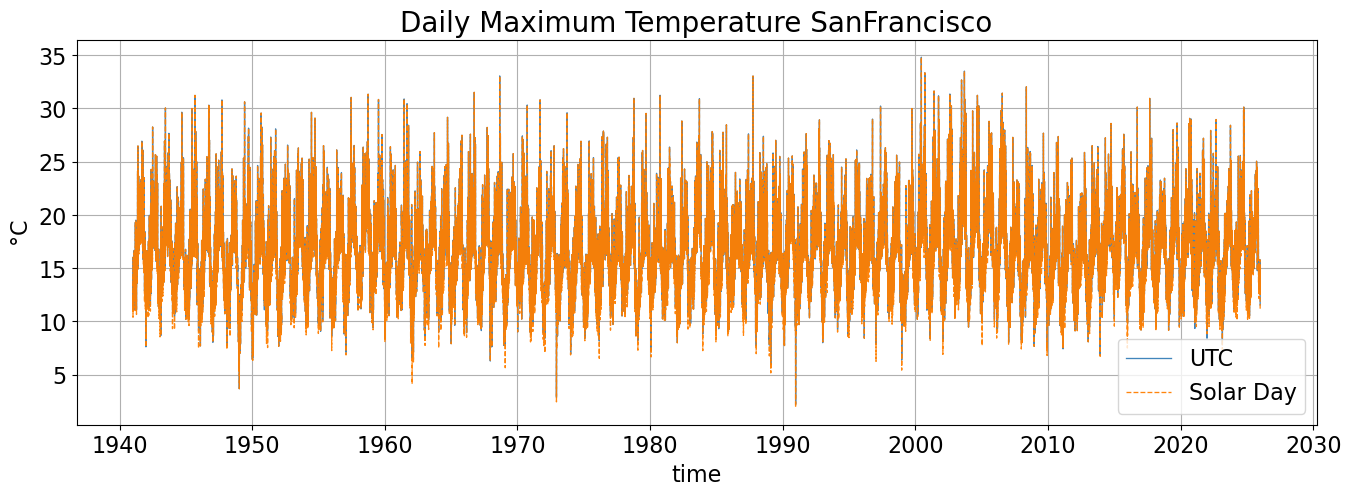

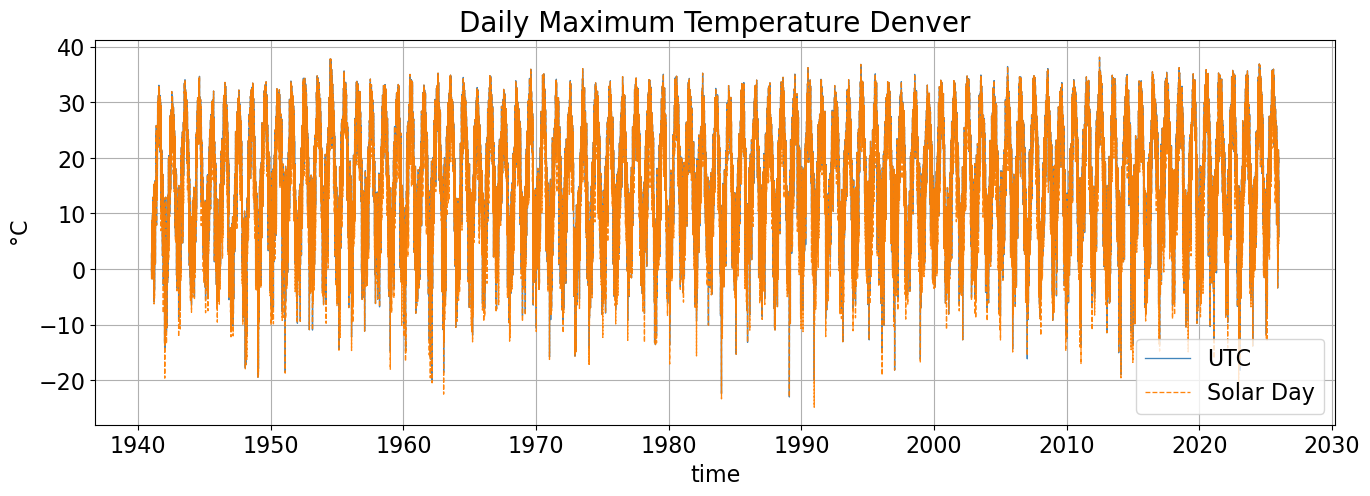

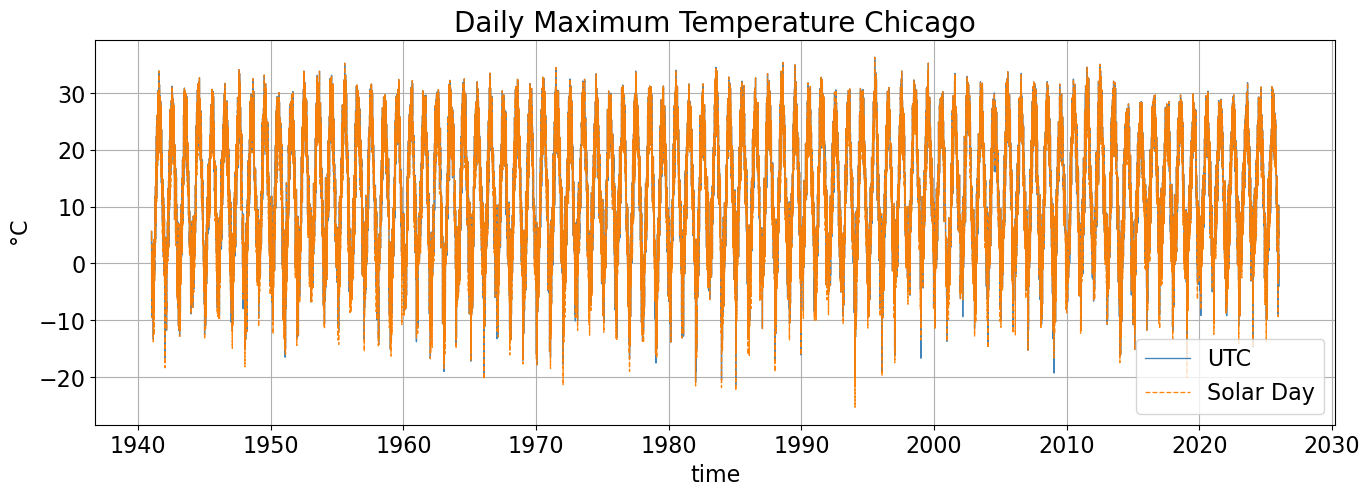

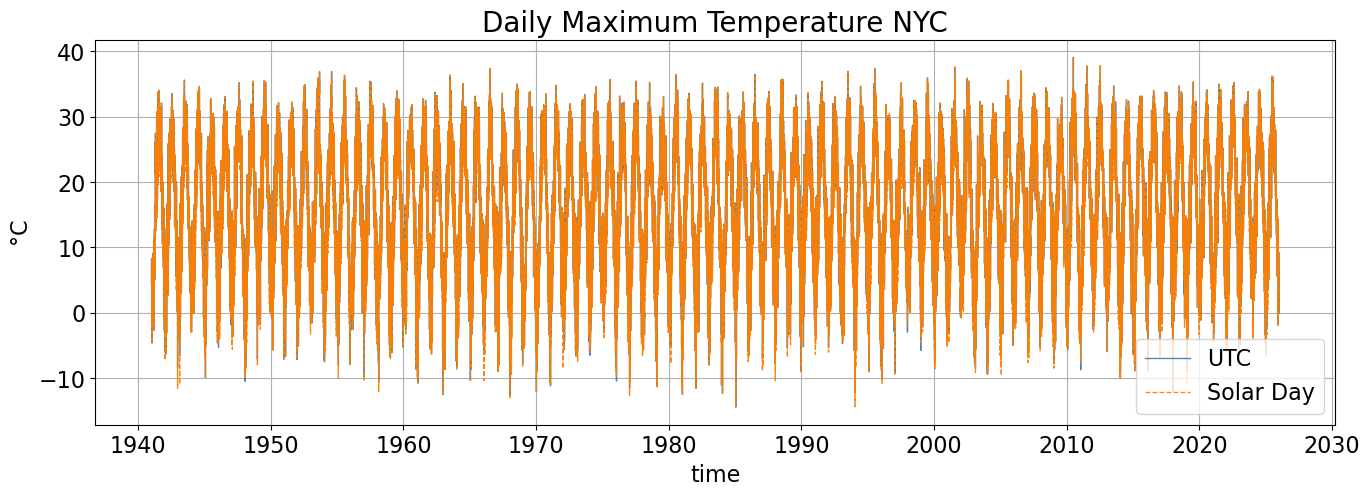

In [45]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'],UTC[ip],color=CB_color[0],linewidth=0.95,alpha=0.95,label='UTC')
  ax.plot(tmaxSLD['time'],SLD[ip],color=CB_color[1],linewidth=0.95,linestyle='--',alpha=0.95,label='Solar Day')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Daily Maximum Temperature {tip[ip]}',fontsize=20)
  plt.show()

### Interpretation: Full Time Series (1941-2025)

**Figure 5.2: Complete Daily Record for Each City**

This figure shows daily maximum temperatures from 1941-2025 for each city, with UTC in solid blue and SLD in dashed orange.

**What to Observe:**
- **Overall Agreement**: How closely do the two lines track each other?
- **Systematic Separation**: Are they consistently offset by a fixed amount, or does the gap vary?
- **Long-Term Trends**: Are both datasets showing similar warming (or cooling) trends over 85 years?
- **Seasonal Oscillation**: Clear annual cycles visible as regular peaks and troughs
- **Interannual Variability**: Some years are warmer/cooler than others; do both conventions capture this?

**Key Questions:**
- If one line is consistently above the other, which convention tends to report higher temperatures?
- Are the differences growing/shrinking over the 85-year record?
- During heat waves (sudden spikes), do UTC and SLD agree or diverge?
- Which cities show largest UTC-SLD divergence in the full record?

**Longitudinal Effect:**
Compare patterns from west to east (Fairbanks → NYC) to see how the UTC-SLD separation varies with longitude.

**Step 5.3: Summer Season Zoom (June-August 2001)**

Focus on a single summer season to highlight day-to-day UTC-SLD differences:

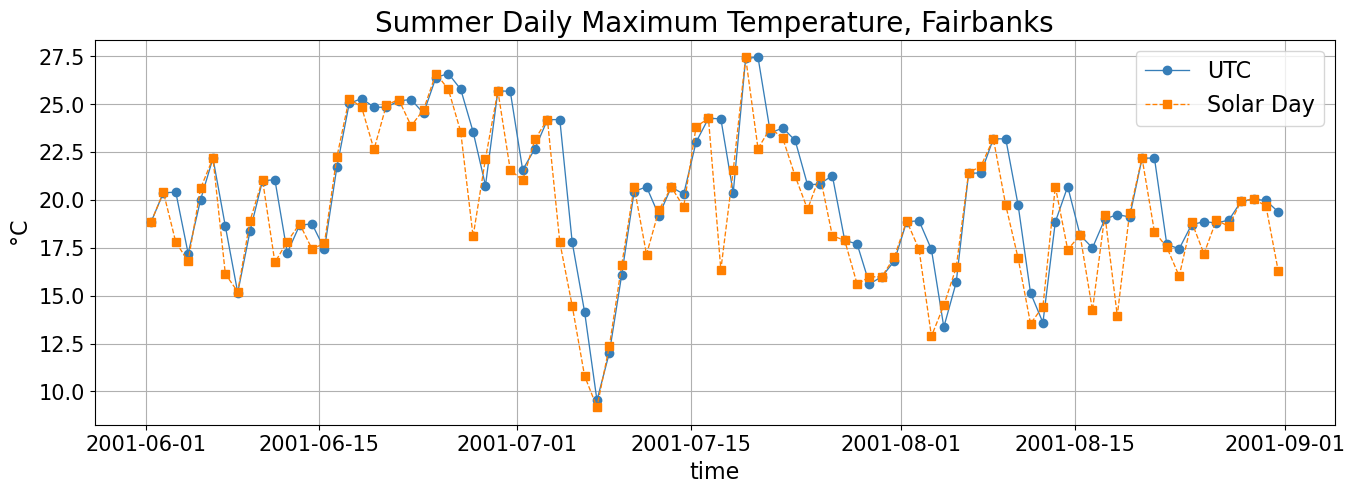

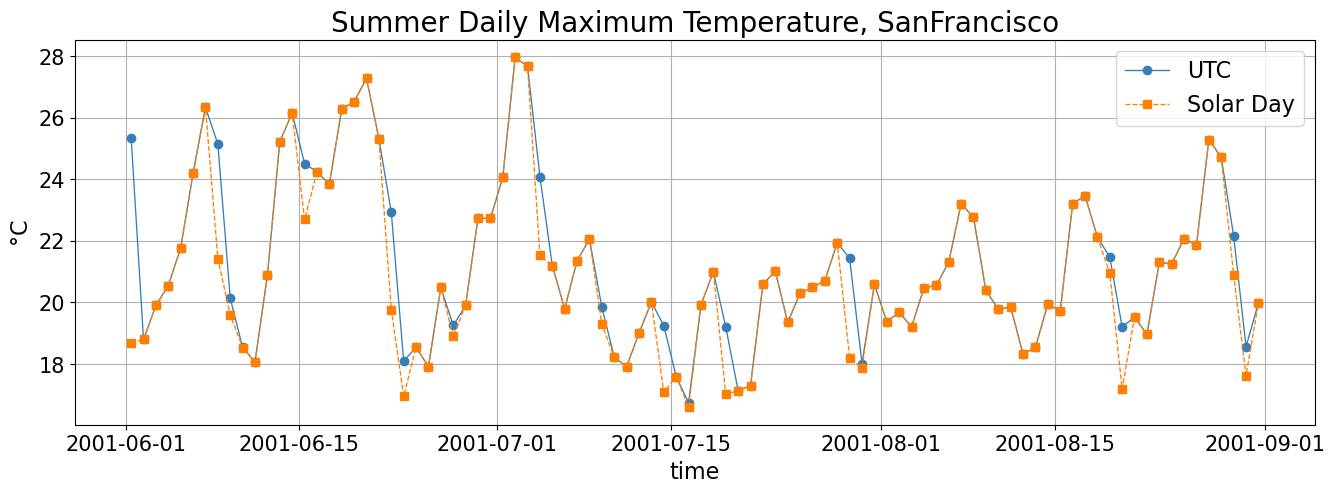

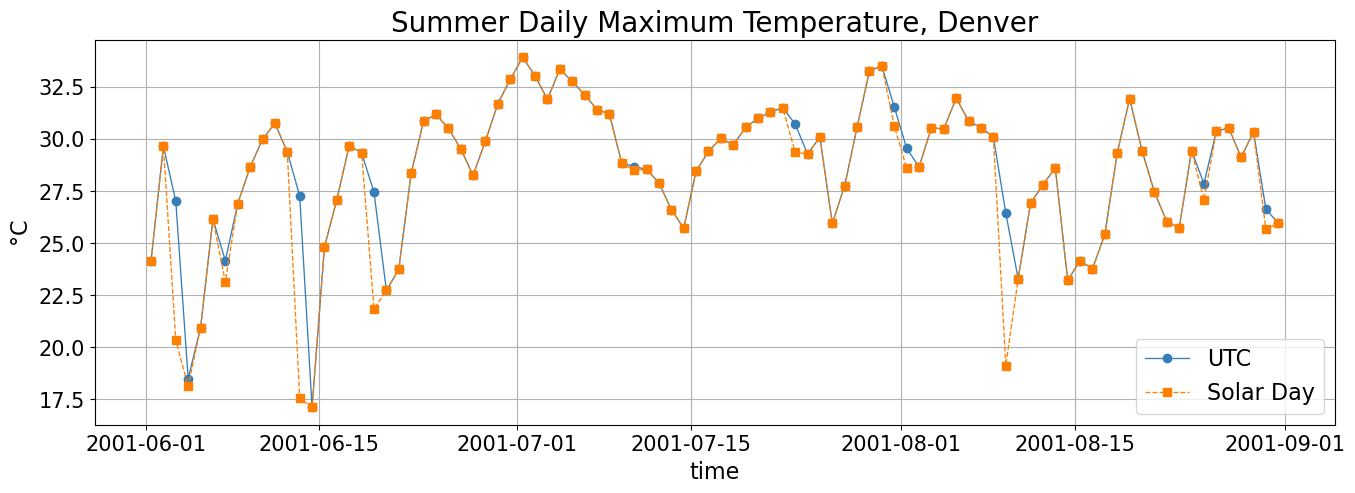

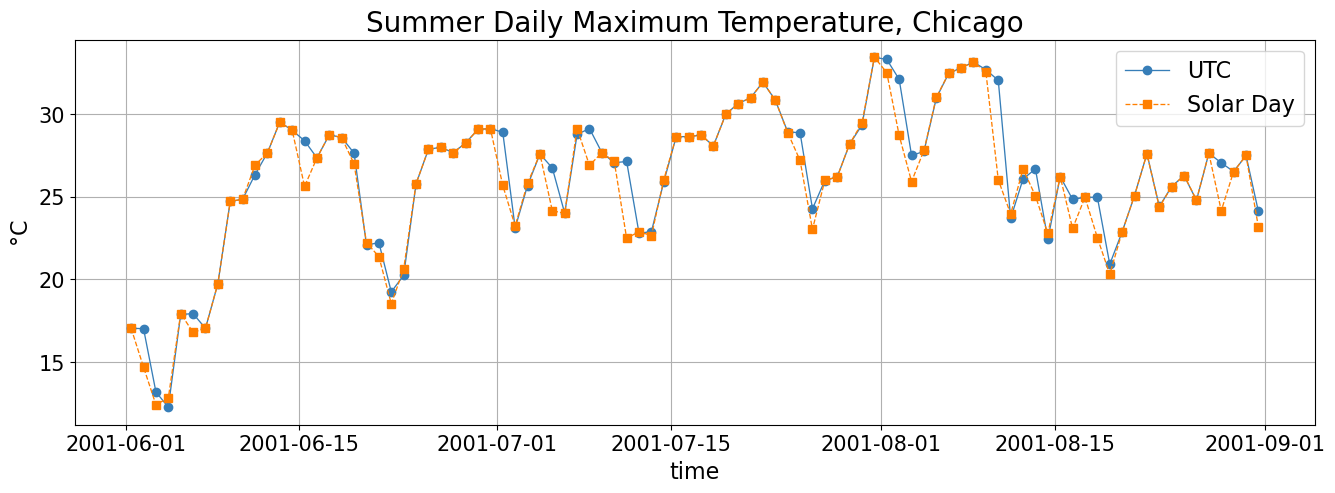

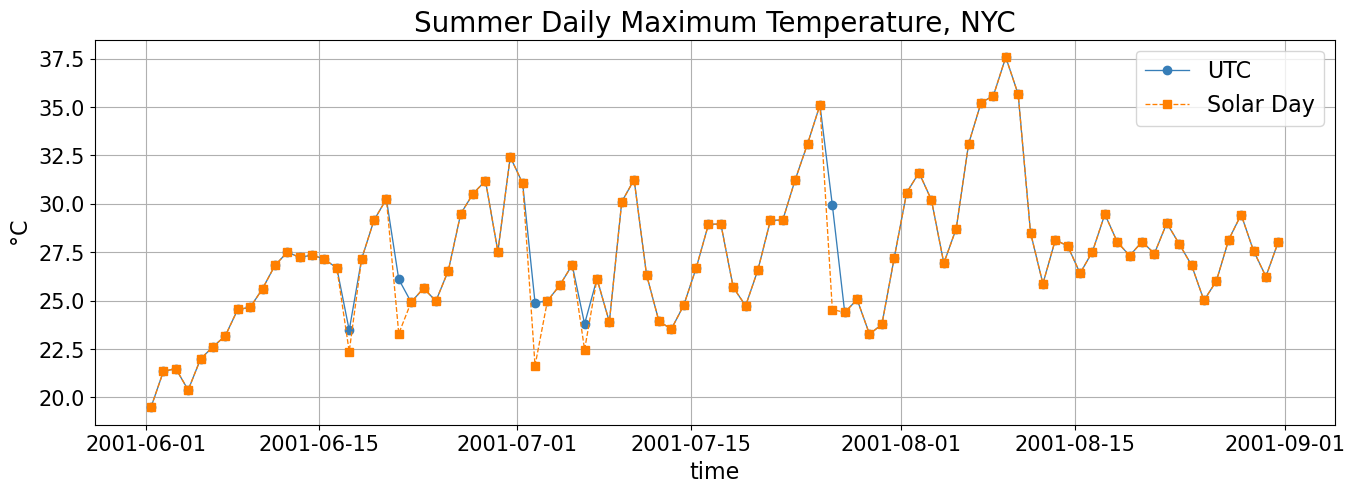

In [46]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].sel(time=UTC[i].time.dt.month.isin([6,7,8])).sel(time=slice('2001-06-01','2001-08-31')),UTC[ip].sel(time=UTC[i].time.dt.month.isin([6,7,8])).sel(time=slice('2001-06-01','2001-08-31')),marker='o',color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'].sel(time=SLD[i].time.dt.month.isin([6,7,8])).sel(time=slice('2001-06-01','2001-08-31')),SLD[ip].sel(time=SLD[i].time.dt.month.isin([6,7,8])).sel(time=slice('2001-06-01','2001-08-31')),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=15)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Summer Daily Maximum Temperature, {tip[ip]}',fontsize=20)
  plt.show()

### Interpretation: Summer Season Detail (June-August 2001)

**Figure 5.3: High-Resolution Summer Comparison**

This figure zooms into a single summer season (June 1 – August 31, 2001) with daily markers (circles for UTC, squares for SLD).

**Why Summer Matters:**
- Highest absolute temperatures occur in summer
- UTC-SLD differences, though small in magnitude, may have largest practical impact (%)
- Heat-sensitive applications (agriculture, health, energy) peak in summer
- Differences in "hottest day" identification can affect extreme value statistics

**Daily-Scale Observations:**
- **Markers**: Circles (UTC) vs. squares (SLD) show day-to-day pair-wise differences
- **Peak Shifts**: Do UTC and SLD identify different dates as the warmest?
- **Multi-Day Events**: During heat waves (sustained high temperatures), which convention maintains higher values?
- **Day-to-Day Variability**: Is the UTC-SLD gap constant or variable?

**Practical Implication:**
For heat wave or extreme temperature definitions that depend on thresholds, shifting between UTC and SLD conventions could change:
- Which days exceed a heat threshold
- Duration of heat wave events
- Magnitude of exceeding the threshold

**Step 5.4: Winter Season Zoom (First 90 Days of Year)**

Compare UTC and SLD behavior during winter conditions (typically lower temperatures):

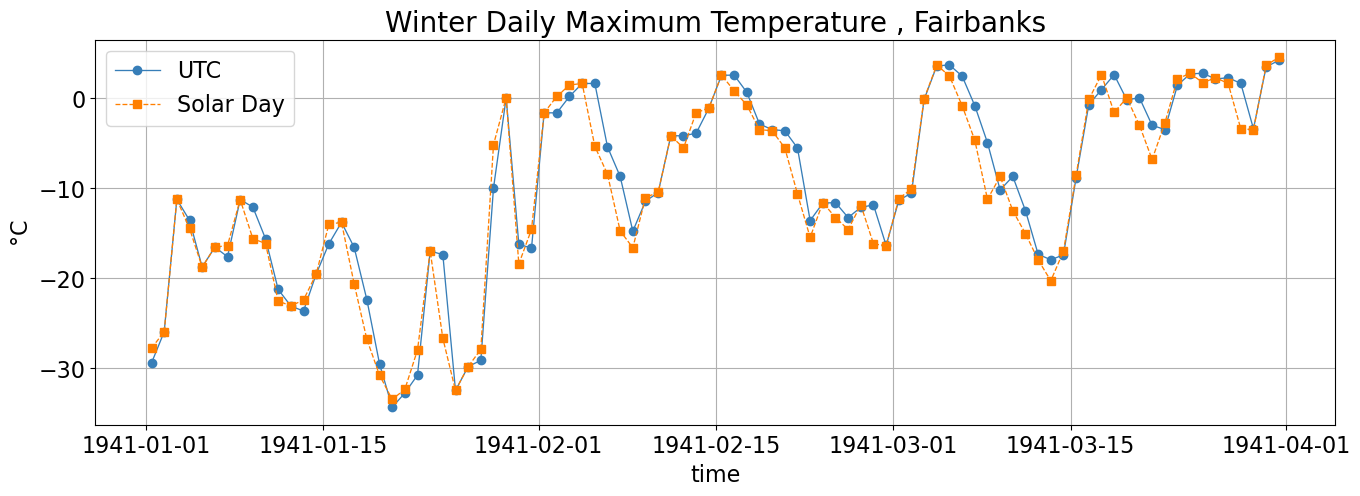

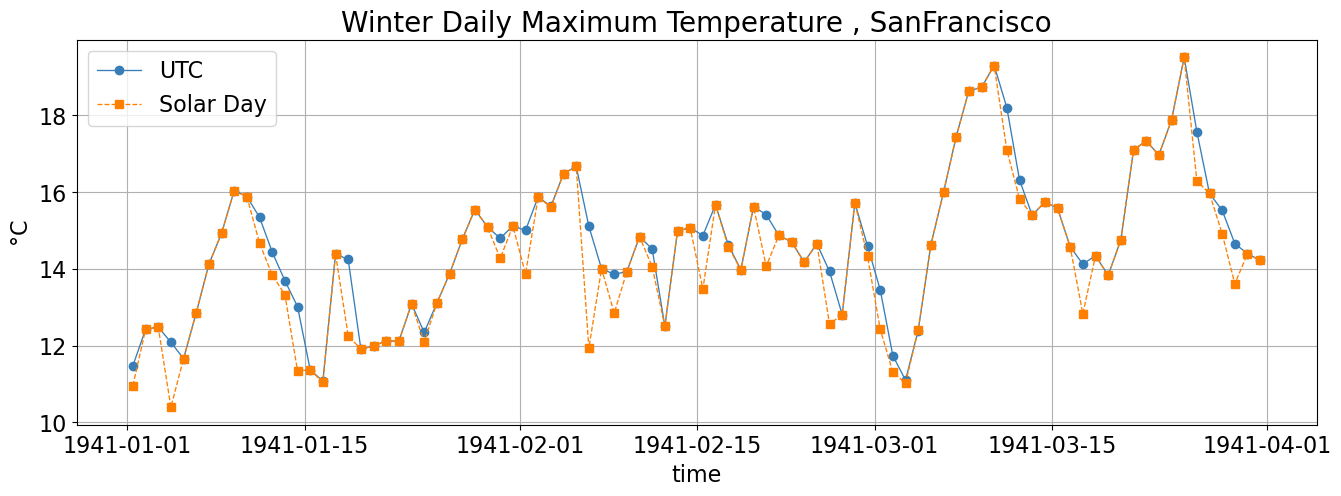

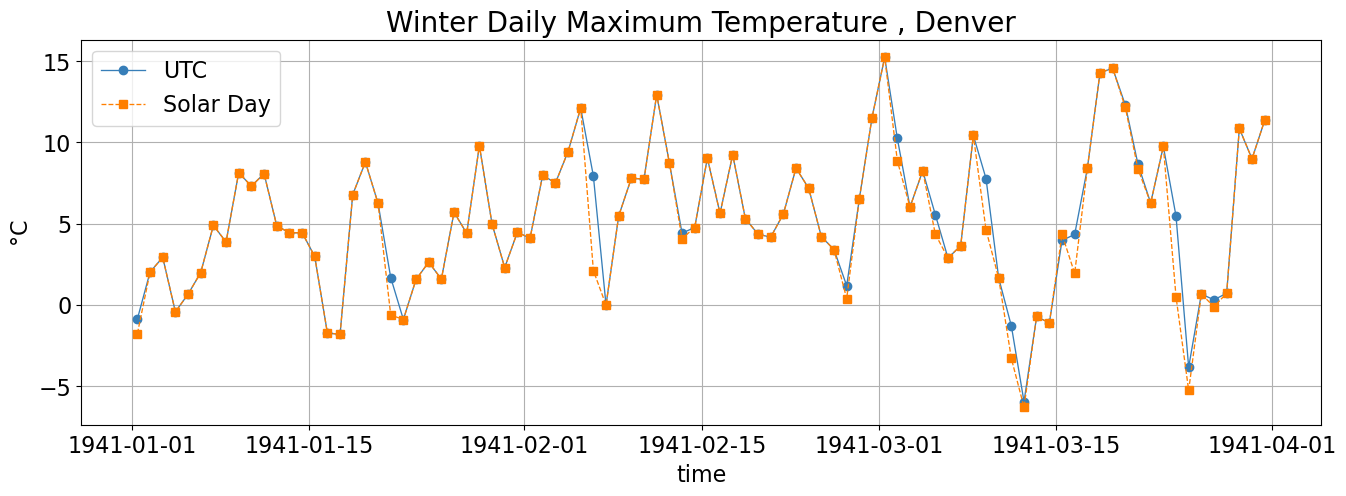

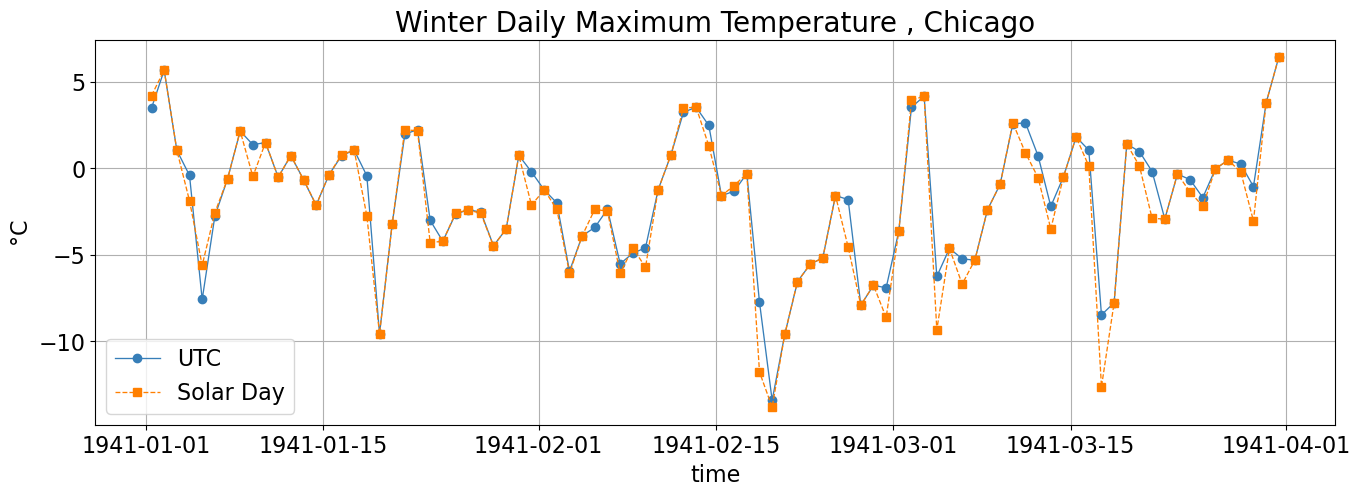

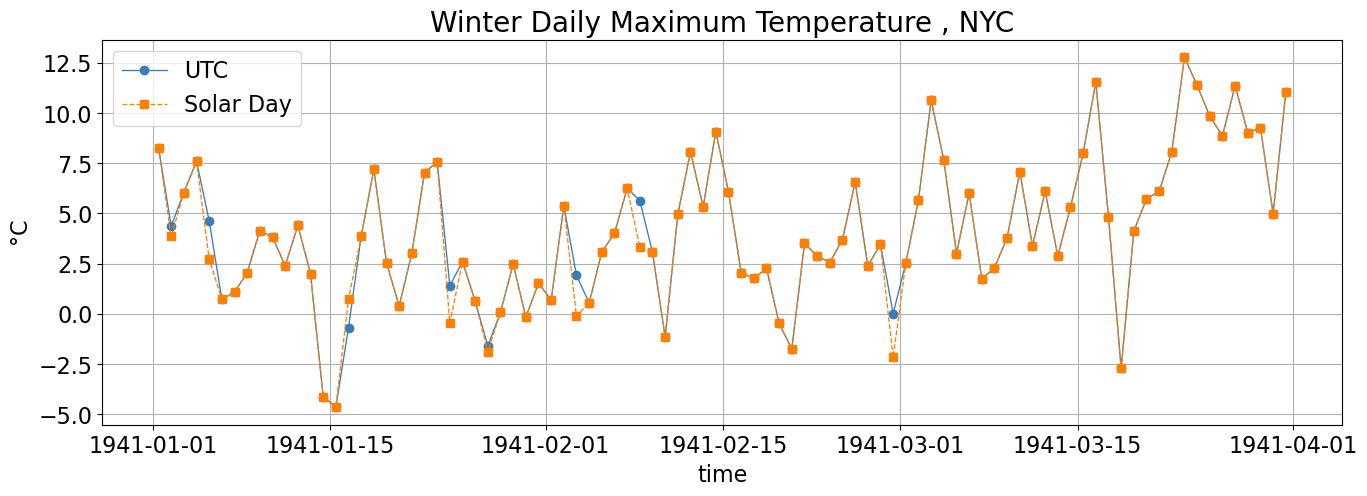

In [47]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].isel(time=slice(0,90)),UTC[ip].isel(time=slice(0,90)),marker='o',color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'].isel(time=slice(0,90)),SLD[ip].isel(time=slice(0,90)),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Winter Daily Maximum Temperature , {tip[ip]}',fontsize=20)
  plt.show()

### Interpretation: Winter Season Detail (January-March, First 90 Days)

**Figure 5.4: Winter Comparison**

This figure examines the first 90 days of the year (January-March, Northern Hemisphere winter) with daily markers for each city.

**Why Winter Comparison Matters:**
- **Opposite Temperature Regime**: Winter has lowest absolute temperatures and different diurnal cycle
- **Baseline Difference**: Comparing summer vs. winter magnitude of UTC-SLD differences shows if the effect scales with temperature
- **Seasonal Asymmetry**: Do UTC-SLD differences have the same magnitude in winter as summer, or is there asymmetry?
- **Cold Extremes**: Heat wave studies focus on summer, but cold snaps and frost events are winter phenomena

**Expected Differences from Summer:**
- Typically smaller absolute UTC-SLD differences in winter (smaller temperature magnitudes)
- But potentially larger *percentage* differences if baseline temperatures are lower
- Solar noon geometry effects that cause summer differences should have opposite phase in winter

**Key Observations:**
- Is the UTC vs. SLD separation similar to summer, larger, or smaller?
- Do the two lines cross the same way?
- Which convention gives higher/lower winter maxima?

**Climate Application:**
For frost forecasting and winter agricultural decisions, small differences in recorded maximum temperature can determine whether frost occurred, affecting crop damage assessments and harvest timing.

---

## Summary and Key Findings

### Analysis Overview

This notebook has systematically compared maximum temperature fields derived using two different time conventions:
1. **UTC Time**: Global reference time (UTC midnight)
2. **Solar Day Time**: Local solar day (local solar noon)

### Dimensions of Comparison

**1. Spatial (Step 2)**
- RMSE map shows how UTC-SLD differences vary geographically across North America
- Differences expected to be longitude-dependent

**2. Statistical Distributions (Step 4)**
- Probability density functions reveal distribution shapes
- Scatter plots show paired value relationships
- Box plots compare quartile structures  
- Violin plots display full probability density shapes
- Q-Q plots assess quantile-by-quantile agreement

**3. Temporal (Step 5)**
- Seasonal cycles show systematic variation throughout the year
- Full 85-year time series reveal long-term trends and interannual variability
- Seasonal zooms provide day-to-day detail for summer (heat) and winter (cold) extremes

### Critical Implications

**For Climate Studies:**
- UTC and SLD conventions can yield different climatological statistics
- Extreme value analyses depend on convention choice
- Heat wave / cold snap definitions must account for time convention

**For Applications:**
- Agricultural frost risk assessment affected by which convention used
- Heat stress indices calculated on UTC vs. SLD may disagree
- Baseline climate statistics for impact assessments must specify time convention

**For Data Users:**
- Always verify which time convention is used in climate datasets
- Be cautious when comparing statistics from datasets using different conventions
- Document and justify the choice of time convention in any analysis

### Next Steps

To extend this analysis, consider:
- Examining specific weather types or seasons in more detail
- Computing UTC-SLD differences as a function of cloud cover or atmospheric conditions
- Investigating whether differences are changing over the 85-year record (possibly related to climate change)
- Examining other variables (precipitation, wind speed) under both time conventions